# False discovery rate p-value correction.

### SciPy
I am going to use https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.false_discovery_control.html
It states the parameters:
- ps: 1D array like (the p-vaues to adjust)
- axis: if none, ps is aveled before performing the adjustment
- method: there are two methods
	- 'bh' = Benjamini-Hochberg (for independent or positively dependent)
	- 'by' = Benjaminini-Yekutieli (Controls the FDR under any dependency structure, including arbitrary dependence among the tests).

The tests are not independent so the corrected p-value will be the most conservative one (Bonferroni).
- Add a soft threshold with FDR and then a stronger confirmation with Bonferroni. 

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.multitest as smm
from statsmodels.stats.multitest import multipletests

In [3]:
ldsc_results = pd.read_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation.csv")
hdl_results = pd.read_csv("/home/maria/git/SOROLLA/Results/hdl_genetic_correlation.csv")


In [4]:
display(ldsc_results)

,id_1,label_1,id_2,label_2,rg,se,z,p,gcov_int,gcov_int_se,h2_1,h2_1_se,h2_2,h2_2_se
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.0517,-0.2519,0.8011,0.000400,0.0057,0.1280,0.0131,0.0317,0.0044
1,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.1500,0.5509,0.5817,-0.002800,0.0045,0.0043,0.0014,0.0180,0.0029
2,GCST90011816,cervical-cancer-2,GCST90013410,bcc-1,0.0549,0.0829,0.6613,0.5084,0.036300,0.0055,0.0089,0.0025,0.0315,0.0044
3,GCST90042843,anxiety-treatment-1,GCST90271619,partial-epilepsy-2,-0.1741,0.1330,-1.3089,0.1906,0.008200,0.0071,0.0383,0.0049,0.0468,0.0111
4,GCST003740,adenocarcinoma-barret-oesophagus,GCST90137411,bcc-2,0.0679,0.0479,1.4178,0.1563,0.003000,0.0061,0.2387,0.0309,0.0697,0.0121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6550,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.1419,-1.4469,0.1479,0.005600,0.0072,0.0082,0.0018,0.0469,0.0112
6551,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0353,0.0585,-0.6038,0.5460,0.000029,0.0055,0.0790,0.0060,0.0171,0.0030
6552,GCST007511,alzheimers-late-onset-1,GCST90275149,ADHD-1,0.0530,0.0617,0.8597,0.3900,0.002000,0.0056,0.0540,0.0136,0.2441,0.0144
6553,GCST008465,ANN-PGC-2019,GCST90137411,bcc-2,0.0543,0.0366,1.4844,0.1377,-0.003300,0.0081,0.1606,0.0134,0.0680,0.0149


In [5]:
### TEST BONFERRONI 1
reject_bonf, corrected_p_vals, _, _ = smm.multipletests(ldsc_results['p'], method='bonferroni')

# Replace original 'p' column with corrected p-values
ldsc_results['p_corrected_M1'] = corrected_p_vals
ldsc_results['p_bonf_rejected'] = reject_bonf

In [6]:
### TEST BONFERRONI 2
m = len(ldsc_results)

# Bonferroni corrected p-values
ldsc_results['p_corrected_M2'] = ldsc_results['p'] * m

In [7]:
display(ldsc_results)

,id_1,label_1,id_2,label_2,rg,se,z,p,gcov_int,gcov_int_se,h2_1,h2_1_se,h2_2,h2_2_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.0517,-0.2519,0.8011,0.000400,0.0057,0.1280,0.0131,0.0317,0.0044,1.0,False,5251.2105
1,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.1500,0.5509,0.5817,-0.002800,0.0045,0.0043,0.0014,0.0180,0.0029,1.0,False,3813.0435
2,GCST90011816,cervical-cancer-2,GCST90013410,bcc-1,0.0549,0.0829,0.6613,0.5084,0.036300,0.0055,0.0089,0.0025,0.0315,0.0044,1.0,False,3332.5620
3,GCST90042843,anxiety-treatment-1,GCST90271619,partial-epilepsy-2,-0.1741,0.1330,-1.3089,0.1906,0.008200,0.0071,0.0383,0.0049,0.0468,0.0111,1.0,False,1249.3830
4,GCST003740,adenocarcinoma-barret-oesophagus,GCST90137411,bcc-2,0.0679,0.0479,1.4178,0.1563,0.003000,0.0061,0.2387,0.0309,0.0697,0.0121,1.0,False,1024.5465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6550,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.1419,-1.4469,0.1479,0.005600,0.0072,0.0082,0.0018,0.0469,0.0112,1.0,False,969.4845
6551,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0353,0.0585,-0.6038,0.5460,0.000029,0.0055,0.0790,0.0060,0.0171,0.0030,1.0,False,3579.0300
6552,GCST007511,alzheimers-late-onset-1,GCST90275149,ADHD-1,0.0530,0.0617,0.8597,0.3900,0.002000,0.0056,0.0540,0.0136,0.2441,0.0144,1.0,False,2556.4500
6553,GCST008465,ANN-PGC-2019,GCST90137411,bcc-2,0.0543,0.0366,1.4844,0.1377,-0.003300,0.0081,0.1606,0.0134,0.0680,0.0149,1.0,False,902.6235


In [8]:
ldsc_results_no_outliers = ldsc_results[(ldsc_results["p"] >= 0) & (ldsc_results["p"] <= 1)]
display(ldsc_results)

,id_1,label_1,id_2,label_2,rg,se,z,p,gcov_int,gcov_int_se,h2_1,h2_1_se,h2_2,h2_2_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.0517,-0.2519,0.8011,0.000400,0.0057,0.1280,0.0131,0.0317,0.0044,1.0,False,5251.2105
1,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.1500,0.5509,0.5817,-0.002800,0.0045,0.0043,0.0014,0.0180,0.0029,1.0,False,3813.0435
2,GCST90011816,cervical-cancer-2,GCST90013410,bcc-1,0.0549,0.0829,0.6613,0.5084,0.036300,0.0055,0.0089,0.0025,0.0315,0.0044,1.0,False,3332.5620
3,GCST90042843,anxiety-treatment-1,GCST90271619,partial-epilepsy-2,-0.1741,0.1330,-1.3089,0.1906,0.008200,0.0071,0.0383,0.0049,0.0468,0.0111,1.0,False,1249.3830
4,GCST003740,adenocarcinoma-barret-oesophagus,GCST90137411,bcc-2,0.0679,0.0479,1.4178,0.1563,0.003000,0.0061,0.2387,0.0309,0.0697,0.0121,1.0,False,1024.5465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6550,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.1419,-1.4469,0.1479,0.005600,0.0072,0.0082,0.0018,0.0469,0.0112,1.0,False,969.4845
6551,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0353,0.0585,-0.6038,0.5460,0.000029,0.0055,0.0790,0.0060,0.0171,0.0030,1.0,False,3579.0300
6552,GCST007511,alzheimers-late-onset-1,GCST90275149,ADHD-1,0.0530,0.0617,0.8597,0.3900,0.002000,0.0056,0.0540,0.0136,0.2441,0.0144,1.0,False,2556.4500
6553,GCST008465,ANN-PGC-2019,GCST90137411,bcc-2,0.0543,0.0366,1.4844,0.1377,-0.003300,0.0081,0.1606,0.0134,0.0680,0.0149,1.0,False,902.6235


In [9]:
# Perform Benjamini-Yekutieli correction
ldsc_results_no_outliers['adjusted_p_by'] = stats.false_discovery_control(ldsc_results_no_outliers["p"].values, method='by')

# Perform Benjamini-Hochberg correction
ldsc_results_no_outliers['adjusted_p_bh'] = stats.false_discovery_control(ldsc_results_no_outliers["p"].values, method='bh')

# False Discovery Rate (FDR)
reject_FDR, corrected_FDR = smm.fdrcorrection(ldsc_results_no_outliers["p"], method='indep', is_sorted=False)
ldsc_results_no_outliers['adjusted_p_FDR'] = corrected_FDR
ldsc_results_no_outliers['reject_FDR'] = reject_FDR

# See transformed columns
display(ldsc_results_no_outliers.head())

,id_1,label_1,id_2,label_2,rg,se,z,p,gcov_int,gcov_int_se,...,h2_1_se,h2_2,h2_2_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2,adjusted_p_by,adjusted_p_bh,adjusted_p_FDR,reject_FDR
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.0517,-0.2519,0.8011,0.0004,0.0057,...,0.0131,0.0317,0.0044,1.0,False,5251.2105,1.0,0.909729,0.909729,False
1,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.1500,0.5509,0.5817,-0.0028,0.0045,...,0.0014,0.0180,0.0029,1.0,False,3813.0435,1.0,0.767344,0.767344,False
2,GCST90011816,cervical-cancer-2,GCST90013410,bcc-1,0.0549,0.0829,0.6613,0.5084,0.0363,0.0055,...,0.0025,0.0315,0.0044,1.0,False,3332.5620,1.0,0.714222,0.714222,False
3,GCST90042843,anxiety-treatment-1,GCST90271619,partial-epilepsy-2,-0.1741,0.1330,-1.3089,0.1906,0.0082,0.0071,...,0.0049,0.0468,0.0111,1.0,False,1249.3830,1.0,0.382191,0.382191,False
4,GCST003740,adenocarcinoma-barret-oesophagus,GCST90137411,bcc-2,0.0679,0.0479,1.4178,0.1563,0.0030,0.0061,...,0.0309,0.0697,0.0121,1.0,False,1024.5465,1.0,0.333620,0.333620,False


In [10]:
pcorrectedvalue = (0.05/len(ldsc_results))
print(pcorrectedvalue)

7.627765064836003e-06


### Plot differences between p values and corrected p-values

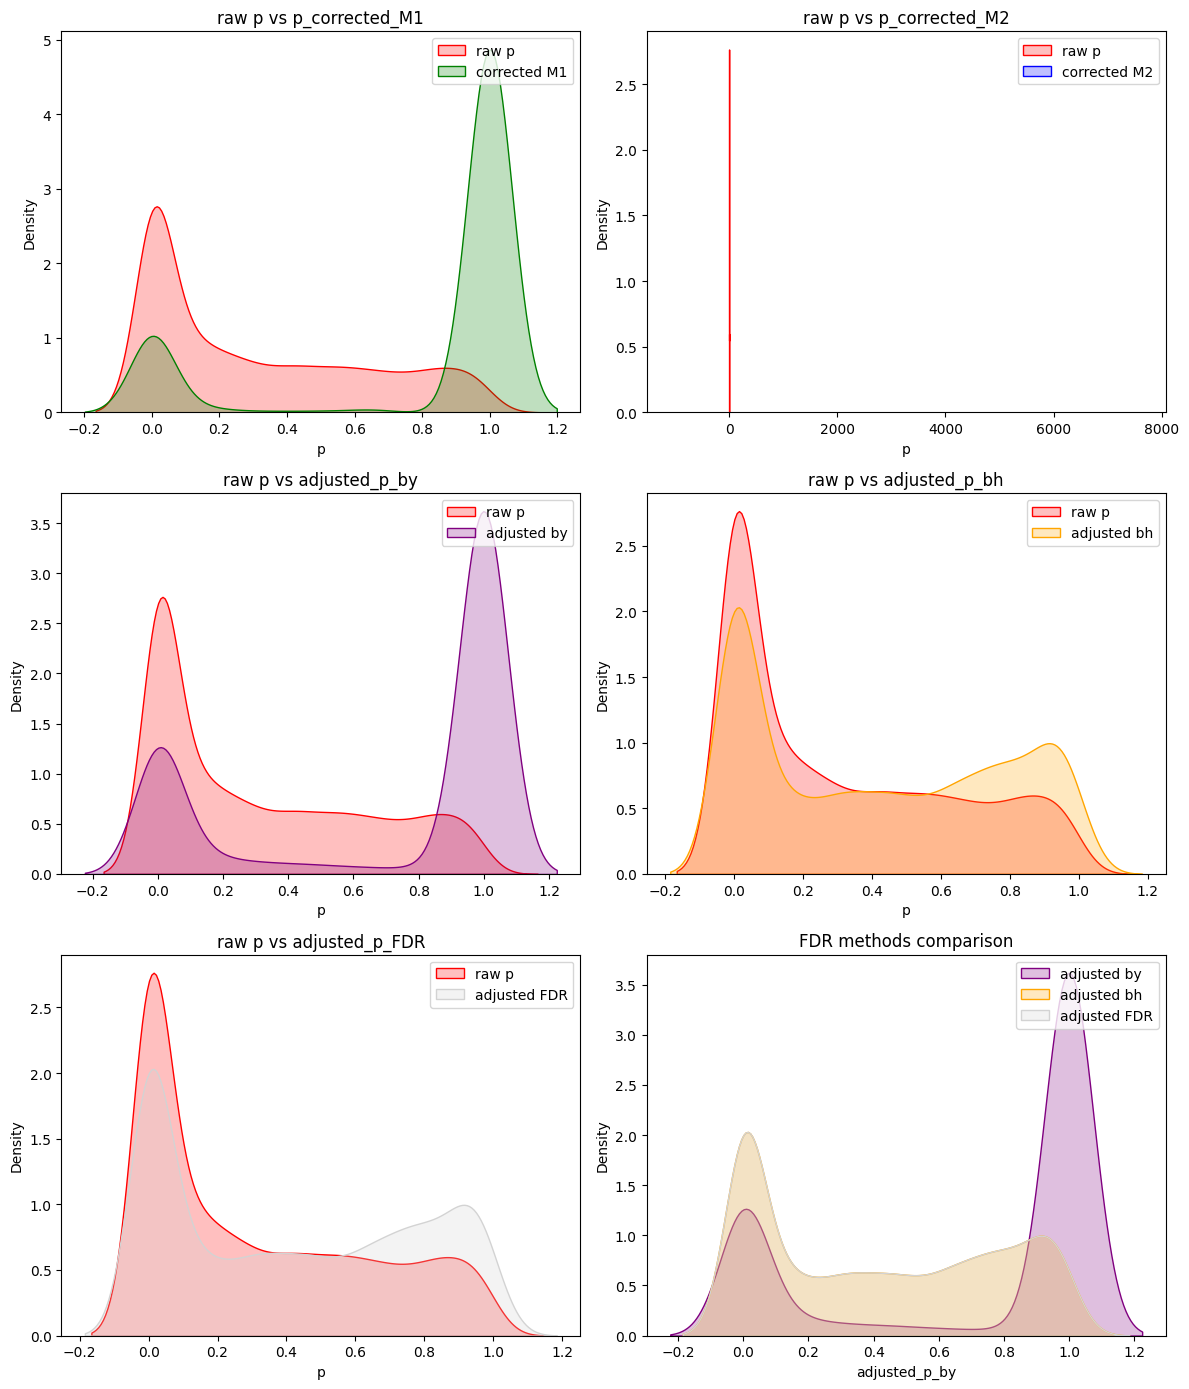

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# p vs p_corrected_M1
sns.kdeplot(ldsc_results_no_outliers['p'], color="red", fill=True, label='raw p', ax=axes[0, 0])
sns.kdeplot(ldsc_results_no_outliers['p_corrected_M1'], color="green", fill=True, label='corrected M1', ax=axes[0, 0])
axes[0, 0].set_title('raw p vs p_corrected_M1')
axes[0, 0].legend()

# p vs p_corrected_M2
sns.kdeplot(ldsc_results_no_outliers['p'], color="red", fill=True, label='raw p', ax=axes[0, 1])
sns.kdeplot(ldsc_results_no_outliers['p_corrected_M2'], color="blue", fill=True, label='corrected M2', ax=axes[0, 1])
axes[0, 1].set_title('raw p vs p_corrected_M2')
axes[0, 1].legend()

# p vs adjusted_p_by
sns.kdeplot(ldsc_results_no_outliers['p'], color="red", fill=True, label='raw p', ax=axes[1, 0])
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_by'], color="purple", fill=True, label='adjusted by', ax=axes[1, 0])
axes[1, 0].set_title('raw p vs adjusted_p_by')
axes[1, 0].legend()

# p vs adjusted_p_bh
sns.kdeplot(ldsc_results_no_outliers['p'], color="red", fill=True, label='raw p', ax=axes[1, 1])
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_bh'], color="orange", fill=True, label='adjusted bh', ax=axes[1, 1])
axes[1, 1].set_title('raw p vs adjusted_p_bh')
axes[1, 1].legend()

# p vs adjusted_p_FDR
sns.kdeplot(ldsc_results_no_outliers['p'], color="red", fill=True, label='raw p', ax=axes[2, 0])
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_FDR'], color="lightgrey", fill=True, label='adjusted FDR', ax=axes[2, 0])
axes[2, 0].set_title('raw p vs adjusted_p_FDR')
axes[2, 0].legend()

# FDR methods comparison
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_by'], color="purple", fill=True, label='adjusted by', ax=axes[2, 1])
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_bh'], color="orange", fill=True, label='adjusted bh', ax=axes[2, 1])
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_FDR'], color="lightgrey", fill=True, label='adjusted FDR', ax=axes[2, 1])
axes[2, 1].set_title('FDR methods comparison')
axes[2, 1].legend()

plt.tight_layout()
plt.show()

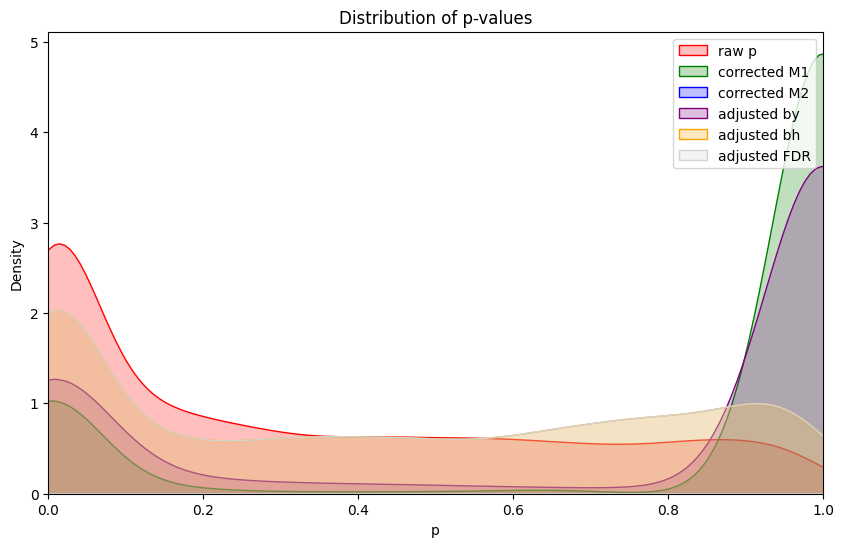

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(ldsc_results_no_outliers['p'], color="red", fill=True, label='raw p')
sns.kdeplot(ldsc_results_no_outliers['p_corrected_M1'], color="green", fill=True, label='corrected M1')
sns.kdeplot(ldsc_results_no_outliers['p_corrected_M2'], color="blue", fill=True, label='corrected M2')
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_by'], color="purple", fill=True, label='adjusted by')
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_bh'], color="orange", fill=True, label='adjusted bh')
sns.kdeplot(ldsc_results_no_outliers['adjusted_p_FDR'], color="lightgrey", fill=True, label='adjusted FDR')

plt.xlim(0, 1)
plt.title('Distribution of p-values')
plt.legend()
plt.show()

In [13]:
display(ldsc_results_no_outliers)

,id_1,label_1,id_2,label_2,rg,se,z,p,gcov_int,gcov_int_se,...,h2_1_se,h2_2,h2_2_se,p_corrected_M1,p_bonf_rejected,p_corrected_M2,adjusted_p_by,adjusted_p_bh,adjusted_p_FDR,reject_FDR
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.0517,-0.2519,0.8011,0.000400,0.0057,...,0.0131,0.0317,0.0044,1.0,False,5251.2105,1.0,0.909729,0.909729,False
1,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.1500,0.5509,0.5817,-0.002800,0.0045,...,0.0014,0.0180,0.0029,1.0,False,3813.0435,1.0,0.767344,0.767344,False
2,GCST90011816,cervical-cancer-2,GCST90013410,bcc-1,0.0549,0.0829,0.6613,0.5084,0.036300,0.0055,...,0.0025,0.0315,0.0044,1.0,False,3332.5620,1.0,0.714222,0.714222,False
3,GCST90042843,anxiety-treatment-1,GCST90271619,partial-epilepsy-2,-0.1741,0.1330,-1.3089,0.1906,0.008200,0.0071,...,0.0049,0.0468,0.0111,1.0,False,1249.3830,1.0,0.382191,0.382191,False
4,GCST003740,adenocarcinoma-barret-oesophagus,GCST90137411,bcc-2,0.0679,0.0479,1.4178,0.1563,0.003000,0.0061,...,0.0309,0.0697,0.0121,1.0,False,1024.5465,1.0,0.333620,0.333620,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6550,GCST90041833,breast-neoplasm-2,GCST90271619,partial-epilepsy-2,-0.2053,0.1419,-1.4469,0.1479,0.005600,0.0072,...,0.0018,0.0469,0.0112,1.0,False,969.4845,1.0,0.321026,0.321026,False
6551,GCST009979,mdd-1,GCST90435597,skin-neoplasm,-0.0353,0.0585,-0.6038,0.5460,0.000029,0.0055,...,0.0060,0.0171,0.0030,1.0,False,3579.0300,1.0,0.742691,0.742691,False
6552,GCST007511,alzheimers-late-onset-1,GCST90275149,ADHD-1,0.0530,0.0617,0.8597,0.3900,0.002000,0.0056,...,0.0136,0.2441,0.0144,1.0,False,2556.4500,1.0,0.612041,0.612041,False
6553,GCST008465,ANN-PGC-2019,GCST90137411,bcc-2,0.0543,0.0366,1.4844,0.1377,-0.003300,0.0081,...,0.0134,0.0680,0.0149,1.0,False,902.6235,1.0,0.306806,0.306806,False


In [ ]:
#Save the DataFrame with adjusted values back to a new CSV file
# ldsc_results.to_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation_pcorrected.csv", index=False)